# Superstore Sales Data Analysis
## A Complete Data Analytics Project

**Project Level:** Beginner-to-Intermediate (Fresher Portfolio)
**Tools Used:** Python (Pandas, Matplotlib, Seaborn), Excel, SQL, Power BI

---

## 1. Import Libraries and Load Data

In [2]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

# Set visualization style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

# Load the dataset
df = pd.read_csv('../Data/superstore_sales.csv', encoding='cp1252')

# Display basic info
print("=" * 60)
print("SUPERSTORE SALES DATASET - BASIC INFORMATION")
print("=" * 60)
print(f"\nDataset Shape: {df.shape[0]} rows, {df.shape[1]} columns")
print(f"\nColumn Names:")
for col in df.columns:
    print(f"  - {col}")

SUPERSTORE SALES DATASET - BASIC INFORMATION

Dataset Shape: 8399 rows, 21 columns

Column Names:
  - Row ID
  - Order ID
  - Order Date
  - Order Priority
  - Order Quantity
  - Sales
  - Discount
  - Ship Mode
  - Profit
  - Unit Price
  - Shipping Cost
  - Customer Name
  - Province
  - Region
  - Customer Segment
  - Product Category
  - Product Sub-Category
  - Product Name
  - Product Container
  - Product Base Margin
  - Ship Date


---

## 2. Data Exploration

In [3]:
# Display first few rows
print("=" * 60)
print("FIRST 5 ROWS")
print("=" * 60)
df.head()

FIRST 5 ROWS


,Row ID,Order ID,Order Date,Order Priority,Order Quantity,Sales,Discount,Ship Mode,Profit,Unit Price,Shipping Cost,Customer Name,Province,Region,Customer Segment,Product Category,Product Sub-Category,Product Name,Product Container,Product Base Margin,Ship Date
0,1,3,10/13/2010,Low,6,261.5400,0.04,Regular Air,-213.25,38.94,35.00,Muhammed MacIntyre,Nunavut,Nunavut,Small Business,Office Supplies,Storage & Organization,"Eldon Base for stackable storage shelf, platinum",Large Box,0.80,10/20/2010
1,49,293,10/1/2012,High,49,10123.0200,0.07,Delivery Truck,457.81,208.16,68.02,Barry French,Nunavut,Nunavut,Consumer,Office Supplies,Appliances,"1.7 Cubic Foot Compact ""Cube"" Office Refrigera...",Jumbo Drum,0.58,10/2/2012
2,50,293,10/1/2012,High,27,244.5700,0.01,Regular Air,46.71,8.69,2.99,Barry French,Nunavut,Nunavut,Consumer,Office Supplies,Binders and Binder Accessories,"Cardinal Slant-D¨ Ring Binder, Heavy Gauge Vinyl",Small Box,0.39,10/3/2012
3,80,483,7/10/2011,High,30,4965.7595,0.08,Regular Air,1198.97,195.99,3.99,Clay Rozendal,Nunavut,Nunavut,Corporate,Technology,Telephones and Communication,R380,Small Box,0.58,7/12/2011
4,85,515,8/28/2010,Not Specified,19,394.2700,0.08,Regular Air,30.94,21.78,5.94,Carlos Soltero,Nunavut,Nunavut,Consumer,Office Supplies,Appliances,Holmes HEPA Air Purifier,Medium Box,0.50,8/30/2010


In [4]:
# Check data types
print("\n" + "=" * 60)
print("DATA TYPES")
print("=" * 60)
df.dtypes


DATA TYPES


Row ID                    int64
Order ID                  int64
Order Date                  str
Order Priority              str
Order Quantity            int64
Sales                   float64
Discount                float64
Ship Mode                   str
Profit                  float64
Unit Price              float64
Shipping Cost           float64
Customer Name               str
Province                    str
Region                      str
Customer Segment            str
Product Category            str
Product Sub-Category        str
Product Name                str
Product Container           str
Product Base Margin     float64
Ship Date                   str
dtype: object

In [5]:
# Statistical summary
print("\n" + "=" * 60)
print("STATISTICAL SUMMARY")
print("=" * 60)
df.describe()


STATISTICAL SUMMARY


,Row ID,Order ID,Order Quantity,Sales,Discount,Profit,Unit Price,Shipping Cost,Product Base Margin
count,8399.000000,8399.000000,8399.000000,8399.000000,8399.000000,8399.000000,8399.000000,8399.000000,8336.000000
mean,4200.000000,29965.179783,25.571735,1775.878179,0.049671,181.184424,89.346259,12.838557,0.512513
std,2424.726789,17260.883447,14.481071,3585.050525,0.031823,1196.653371,290.354383,17.264052,0.135589
min,1.000000,3.000000,1.000000,2.240000,0.000000,-14140.700000,0.990000,0.490000,0.350000
25%,2100.500000,15011.500000,13.000000,143.195000,0.020000,-83.315000,6.480000,3.300000,0.380000
50%,4200.000000,29857.000000,26.000000,449.420000,0.050000,-1.500000,20.990000,6.070000,0.520000
75%,6299.500000,44596.000000,38.000000,1709.320000,0.080000,162.750000,85.990000,13.990000,0.590000
max,8399.000000,59973.000000,50.000000,89061.050000,0.250000,27220.690000,6783.020000,164.730000,0.850000


---

## 3. Data Cleaning

In [6]:
### 3.1 Check Missing Values

In [7]:
# Check missing values
print("=" * 60)
print("MISSING VALUES CHECK")
print("=" * 60)

missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Percentage': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0]

if len(missing_df) > 0:
    print(missing_df)
else:
    print("No missing values found!")

print(f"\nTotal missing values: {df.isnull().sum().sum()}")

MISSING VALUES CHECK
                     Missing Count  Percentage
Product Base Margin             63        0.75

Total missing values: 63


In [8]:
### 3.2 Check Duplicates

In [9]:
# Check for duplicates
print("\n" + "=" * 60)
print("DUPLICATES CHECK")
print("=" * 60)

duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")


DUPLICATES CHECK
Number of duplicate rows: 0


In [10]:
### 3.3 Handle Missing Values

In [11]:
# Handle missing values
print("\n" + "=" * 60)
print("HANDLING MISSING VALUES")
print("=" * 60)

# Check which columns have missing values
cols_with_missing = df.columns[df.isnull().any()].tolist()
print(f"Columns with missing values: {cols_with_missing}")

# For 'Product Base Margin', fill with median (numerical column)
if 'Product Base Margin' in cols_with_missing:
    median_margin = df['Product Base Margin'].median()
    df['Product Base Margin'].fillna(median_margin, inplace=True)
    print(f"Filled 'Product Base Margin' with median: {median_margin:.2f}")

# Verify no missing values remain
print(f"\nMissing values after cleaning: {df.isnull().sum().sum()}")


HANDLING MISSING VALUES
Columns with missing values: ['Product Base Margin']
Filled 'Product Base Margin' with median: 0.52

Missing values after cleaning: 63


In [12]:
### 3.4 Correct Data Types

In [13]:
# Convert date columns to datetime
print("\n" + "=" * 60)
print("CORRECTING DATA TYPES")
print("=" * 60)

df['Order Date'] = pd.to_datetime(df['Order Date'], format='%m/%d/%Y')
df['Ship Date'] = pd.to_datetime(df['Ship Date'], format='%m/%d/%Y')

print("Converted 'Order Date' and 'Ship Date' to datetime format")
print(f"\nOrder Date range: {df['Order Date'].min()} to {df['Order Date'].max()}")
print(f"Ship Date range: {df['Ship Date'].min()} to {df['Ship Date'].max()}")


CORRECTING DATA TYPES
Converted 'Order Date' and 'Ship Date' to datetime format

Order Date range: 2009-01-01 00:00:00 to 2012-12-30 00:00:00
Ship Date range: 2009-01-02 00:00:00 to 2012-12-30 00:00:00


In [14]:
### 3.5 Create Calculated Columns

In [15]:
# Create useful calculated columns
print("\n" + "=" * 60)
print("CREATING CALCULATED COLUMNS")
print("=" * 60)

# Extract year, month, quarter from Order Date
df['Order Year'] = df['Order Date'].dt.year
df['Order Month'] = df['Order Date'].dt.month
df['Order Month Name'] = df['Order Date'].dt.month_name()
df['Order Quarter'] = df['Order Date'].dt.quarter
df['Order Day of Week'] = df['Order Date'].dt.day_name()

# Calculate shipping days
df['Shipping Days'] = (df['Ship Date'] - df['Order Date']).dt.days

# Calculate profit margin
df['Profit Margin'] = (df['Profit'] / df['Sales'] * 100).round(2)

# Calculate order value
df['Order Value'] = df['Sales'] * df['Order Quantity']

print("Created columns:")
print("  - Order Year, Order Month, Order Month Name, Order Quarter, Order Day of Week")
print("  - Shipping Days")
print("  - Profit Margin (%)")
print("  - Order Value")

print("\n" + "=" * 60)
print("DATA CLEANING COMPLETE!")
print("=" * 60)


CREATING CALCULATED COLUMNS
Created columns:
  - Order Year, Order Month, Order Month Name, Order Quarter, Order Day of Week
  - Shipping Days
  - Profit Margin (%)
  - Order Value

DATA CLEANING COMPLETE!


---

## 4. Exploratory Data Analysis

In [16]:
### 4.1 Overall Sales and Profit Analysis

In [17]:
# Key Metrics
print("=" * 60)
print("KEY PERFORMANCE METRICS")
print("=" * 60)

total_sales = df['Sales'].sum()
total_profit = df['Profit'].sum()
total_orders = df['Order ID'].nunique()
profit_margin = (total_profit / total_sales * 100)
avg_order_value = total_sales / total_orders

print(f"Total Sales: ${total_sales:,.2f}")
print(f"Total Profit: ${total_profit:,.2f}")
print(f"Profit Margin: {profit_margin:.2f}%")
print(f"Number of Orders: {total_orders:,}")
print(f"Average Order Value: ${avg_order_value:,.2f}")

KEY PERFORMANCE METRICS
Total Sales: $14,915,600.82
Total Profit: $1,521,767.98
Profit Margin: 10.20%
Number of Orders: 5,496
Average Order Value: $2,713.90


In [18]:
### 4.2 Category-wise Performance

In [19]:
# Category performance
print("\n" + "=" * 60)
print("CATEGORY-WISE PERFORMANCE")
print("=" * 60)

category_perf = df.groupby('Product Category').agg({
    'Sales': 'sum',
    'Profit': 'sum',
    'Order ID': 'nunique',
    'Profit Margin': 'mean'
}).round(2)
category_perf.columns = ['Total Sales', 'Total Profit', 'Order Count', 'Avg Profit Margin %']
category_perf = category_perf.sort_values('Total Sales', ascending=False)
print(category_perf)


CATEGORY-WISE PERFORMANCE
                  Total Sales  Total Profit  Order Count  Avg Profit Margin %
Product Category                                                             
Technology         5984248.18     886313.52         1858               -11.05
Furniture          5178590.54     117433.03         1561                -7.56
Office Supplies    3752762.10     518021.43         3632               -16.44


In [20]:
### 4.3 Sub-Category Analysis

In [21]:
# Sub-category performance
print("\n" + "=" * 60)
print("SUB-CATEGORY PERFORMANCE (TOP 10)")
print("=" * 60)

subcategory_perf = df.groupby('Product Sub-Category').agg({
    'Sales': 'sum',
    'Profit': 'sum',
    'Order ID': 'nunique'
}).round(2)
subcategory_perf.columns = ['Total Sales', 'Total Profit', 'Order Count']
subcategory_perf = subcategory_perf.sort_values('Total Sales', ascending=False)
print(subcategory_perf.head(10))

# Identify loss-making sub-categories
print("\n" + "-" * 40)
print("LOSS-MAKING SUB-CATEGORIES:")
print("-" * 40)
loss_making = subcategory_perf[subcategory_perf['Total Profit'] < 0]
print(loss_making)


SUB-CATEGORY PERFORMANCE (TOP 10)
                                Total Sales  Total Profit  Order Count
Product Sub-Category                                                  
Office Machines                  2168697.14     307712.93          334
Tables                           1896008.14     -99062.50          355
Telephones and Communication     1889313.80     316951.62          840
Chairs & Chairmats               1761836.55     149649.73          375
Copiers and Fax                  1130361.30     167361.49           87
Storage & Organization           1070182.60       6664.15          537
Binders and Binder Accessories   1022957.59     307413.39          868
Bookcases                         822652.04     -33582.13          188
Computer Peripherals              795875.94      94287.48          731
Appliances                        736991.54      97158.06          423

----------------------------------------
LOSS-MAKING SUB-CATEGORIES:
----------------------------------------
  

In [22]:
### 4.4 Regional Performance

In [23]:
# Regional performance
print("\n" + "=" * 60)
print("REGIONAL PERFORMANCE")
print("=" * 60)

region_perf = df.groupby('Region').agg({
    'Sales': 'sum',
    'Profit': 'sum',
    'Order ID': 'nunique'
}).round(2)
region_perf.columns = ['Total Sales', 'Total Profit', 'Order Count']
region_perf = region_perf.sort_values('Total Sales', ascending=False)
region_perf['Profit Margin %'] = (region_perf['Total Profit'] / region_perf['Total Sales'] * 100).round(2)
print(region_perf)


REGIONAL PERFORMANCE
                       Total Sales  Total Profit  Order Count  Profit Margin %
Region                                                                        
West                    3597549.28     297008.61         1330             8.26
Ontario                 3063212.48     346868.54         1235            11.32
Prarie                  2837304.60     321160.12         1148            11.32
Atlantic                2014248.20     238960.66          748            11.86
Quebec                  1510195.08     140426.65          587             9.30
Yukon                    975867.37      73849.21          396             7.57
Northwest Territories    800847.33     100653.08          269            12.57
Nunavut                  116376.48       2841.11           56             2.44


In [24]:
### 4.5 Customer Segment Analysis

In [25]:
# Customer segment performance
print("\n" + "=" * 60)
print("CUSTOMER SEGMENT PERFORMANCE")
print("=" * 60)

segment_perf = df.groupby('Customer Segment').agg({
    'Sales': 'sum',
    'Profit': 'sum',
    'Order ID': 'nunique',
    'Customer Name': 'nunique'
}).round(2)
segment_perf.columns = ['Total Sales', 'Total Profit', 'Order Count', 'Customer Count']
segment_perf = segment_perf.sort_values('Total Sales', ascending=False)
segment_perf['Profit Margin %'] = (segment_perf['Total Profit'] / segment_perf['Total Sales'] * 100).round(2)
segment_perf['Avg Order Value'] = (segment_perf['Total Sales'] / segment_perf['Order Count']).round(2)
print(segment_perf)


CUSTOMER SEGMENT PERFORMANCE
                  Total Sales  Total Profit  Order Count  Customer Count  \
Customer Segment                                                           
Corporate          5498904.88     599746.00         2002             353   
Home Office        3564763.88     318354.03         1341             246   
Consumer           3063611.08     287959.94         1076             197   
Small Business     2788320.99     315708.01         1077             193   

                  Profit Margin %  Avg Order Value  
Customer Segment                                    
Corporate                   10.91          2746.71  
Home Office                  8.93          2658.29  
Consumer                     9.40          2847.22  
Small Business              11.32          2588.97  


In [26]:
### 4.6 Monthly and Yearly Trends

In [27]:
# Yearly trend
print("\n" + "=" * 60)
print("YEARLY TREND")
print("=" * 60)

yearly_perf = df.groupby('Order Year').agg({
    'Sales': 'sum',
    'Profit': 'sum',
    'Order ID': 'nunique'
}).round(2)
yearly_perf.columns = ['Total Sales', 'Total Profit', 'Order Count']
yearly_perf['Profit Margin %'] = (yearly_perf['Total Profit'] / yearly_perf['Total Sales'] * 100).round(2)
print(yearly_perf)


YEARLY TREND
            Total Sales  Total Profit  Order Count  Profit Margin %
Order Year                                                         
2009         4209139.46     434538.73         1394            10.32
2010         3549680.80     363871.48         1393            10.25
2011         3436816.70     381455.99         1317            11.10
2012         3719963.86     341901.78         1392             9.19


In [28]:
# Monthly trend (combined years)
print("\n" + "=" * 60)
print("MONTHLY TREND (AVERAGE ACROSS YEARS)")
print("=" * 60)

monthly_perf = df.groupby(['Order Month', 'Order Month Name']).agg({
    'Sales': 'sum',
    'Profit': 'sum'
}).round(2).reset_index()
monthly_perf = monthly_perf.sort_values('Order Month')
print(monthly_perf[['Order Month Name', 'Sales', 'Profit']])


MONTHLY TREND (AVERAGE ACROSS YEARS)
   Order Month Name       Sales     Profit
0           January  1444923.38  171520.75
1          February  1180083.78  102429.12
2             March  1273680.93  104799.33
3             April  1216483.44  123906.52
4               May  1160896.38  115628.69
5              June  1030858.51  118703.56
6              July  1141104.35  120965.31
7            August  1115015.33   74585.50
8         September  1337956.96  164352.69
9           October  1383714.44  174016.39
10         November  1163393.37  106670.36
11         December  1467489.96  144189.76


In [29]:
### 4.7 Shipping Performance Analysis

In [30]:
# Shipping performance
print("\n" + "=" * 60)
print("SHIPPING PERFORMANCE")
print("=" * 60)

print(f"Average Shipping Days: {df['Shipping Days'].mean():.1f} days")
print(f"Median Shipping Days: {df['Shipping Days'].median():.1f} days")
print(f"Min Shipping Days: {df['Shipping Days'].min()} days")
print(f"Max Shipping Days: {df['Shipping Days'].max()} days")

# Shipping mode analysis
print("\n" + "-" * 40)
print("SHIPPING MODE PERFORMANCE:")
print("-" * 40)

ship_mode_perf = df.groupby('Ship Mode').agg({
    'Sales': 'sum',
    'Profit': 'sum',
    'Shipping Days': 'mean'
}).round(2)
ship_mode_perf.columns = ['Total Sales', 'Total Profit', 'Avg Shipping Days']
ship_mode_perf = ship_mode_perf.sort_values('Total Sales', ascending=False)
print(ship_mode_perf)


SHIPPING PERFORMANCE
Average Shipping Days: 2.0 days
Median Shipping Days: 2.0 days
Min Shipping Days: 0 days
Max Shipping Days: 92 days

----------------------------------------
SHIPPING MODE PERFORMANCE:
----------------------------------------
                Total Sales  Total Profit  Avg Shipping Days
Ship Mode                                                   
Regular Air      7506303.21    1104692.80               2.04
Delivery Truck   6224878.72     269644.87               2.04
Express Air      1184418.90     147430.31               2.00


In [31]:
### 4.8 Top Products Analysis

In [32]:
# Top 10 products by sales
print("\n" + "=" * 60)
print("TOP 10 PRODUCTS BY SALES")
print("=" * 60)

top_products = df.groupby('Product Name').agg({
    'Sales': 'sum',
    'Profit': 'sum',
    'Order ID': 'nunique'
}).round(2)
top_products.columns = ['Total Sales', 'Total Profit', 'Order Count']
top_products = top_products.sort_values('Total Sales', ascending=False)
print(top_products.head(10))


TOP 10 PRODUCTS BY SALES
                                                    Total Sales  Total Profit  \
Product Name                                                                    
Global Troyª Executive Leather Low-Back Tilter        275941.52      79284.78   
Polycom ViewStationª ISDN Videoconferencing Unit      255303.97     -17771.27   
Canon PC940 Copier                                    210910.68      47705.85   
Riverside Palais Royal Lawyers Bookcase, Royale...    206494.13      14291.57   
Hewlett Packard LaserJet 3310 Copier                  194880.35      73299.61   
Bretford CR8500 Series Meeting Room Furniture         147412.21      -1989.87   
Sharp AL-1530CS Digital Copier                        130046.81      11770.30   
Hewlett-Packard cp1700 [D, PS] Series Color Ink...    128100.43      55281.39   
GBC DocuBind 200 Manual Binding Machine               120342.74      50462.53   
Canon imageCLASS 2200 Advanced Copier                 114173.41     -31885.68   

 

---

## 5. Save Cleaned Data for Excel and SQL

In [33]:
# Save cleaned dataset
df.to_csv('../Data/superstore_cleaned.csv', index=False)
print("Cleaned dataset saved to: ../Data/superstore_cleaned.csv")

# Create summary tables for Excel dashboard
print("\nCreating summary tables for Excel...")

# Monthly summary
monthly_summary = df.groupby(['Order Year', 'Order Month', 'Order Month Name']).agg({
    'Sales': 'sum',
    'Profit': 'sum',
    'Order ID': 'nunique'
}).round(2).reset_index()
monthly_summary.columns = ['Year', 'Month', 'Month Name', 'Sales', 'Profit', 'Orders']
monthly_summary.to_csv('../Excel/monthly_summary.csv', index=False)

# Category summary
category_summary = df.groupby(['Product Category', 'Product Sub-Category']).agg({
    'Sales': 'sum',
    'Profit': 'sum',
    'Order ID': 'nunique'
}).round(2).reset_index()
category_summary.columns = ['Category', 'Sub-Category', 'Sales', 'Profit', 'Orders']
category_summary.to_csv('../Excel/category_summary.csv', index=False)

# Regional summary
region_summary = df.groupby(['Region', 'Province']).agg({
    'Sales': 'sum',
    'Profit': 'sum',
    'Order ID': 'nunique'
}).round(2).reset_index()
region_summary.columns = ['Region', 'Province', 'Sales', 'Profit', 'Orders']
region_summary.to_csv('../Excel/region_summary.csv', index=False)

# Customer segment summary
segment_summary = df.groupby(['Customer Segment', 'Region']).agg({
    'Sales': 'sum',
    'Profit': 'sum',
    'Order ID': 'nunique'
}).round(2).reset_index()
segment_summary.columns = ['Segment', 'Region', 'Sales', 'Profit', 'Orders']
segment_summary.to_csv('../Excel/segment_summary.csv', index=False)

# KPIs summary
kpi_data = {
    'Metric': ['Total Sales', 'Total Profit', 'Profit Margin %', 'Total Orders', 'Average Order Value'],
    'Value': [total_sales, total_profit, profit_margin, total_orders, avg_order_value]
}
kpi_df = pd.DataFrame(kpi_data)
kpi_df.to_csv('../Excel/kpi_summary.csv', index=False)

print("Summary files saved to Excel folder:")
print("  - monthly_summary.csv")
print("  - category_summary.csv")
print("  - region_summary.csv")
print("  - segment_summary.csv")
print("  - kpi_summary.csv")

Cleaned dataset saved to: ../Data/superstore_cleaned.csv

Creating summary tables for Excel...
Summary files saved to Excel folder:
  - monthly_summary.csv
  - category_summary.csv
  - region_summary.csv
  - segment_summary.csv
  - kpi_summary.csv


---

## 6. Visualizations

In [34]:
# Create output directory if it doesn't exist
import os
os.makedirs('../Visualizations', exist_ok=True)

In [35]:
### 6.1 Sales and Profit Trend (Line Chart)

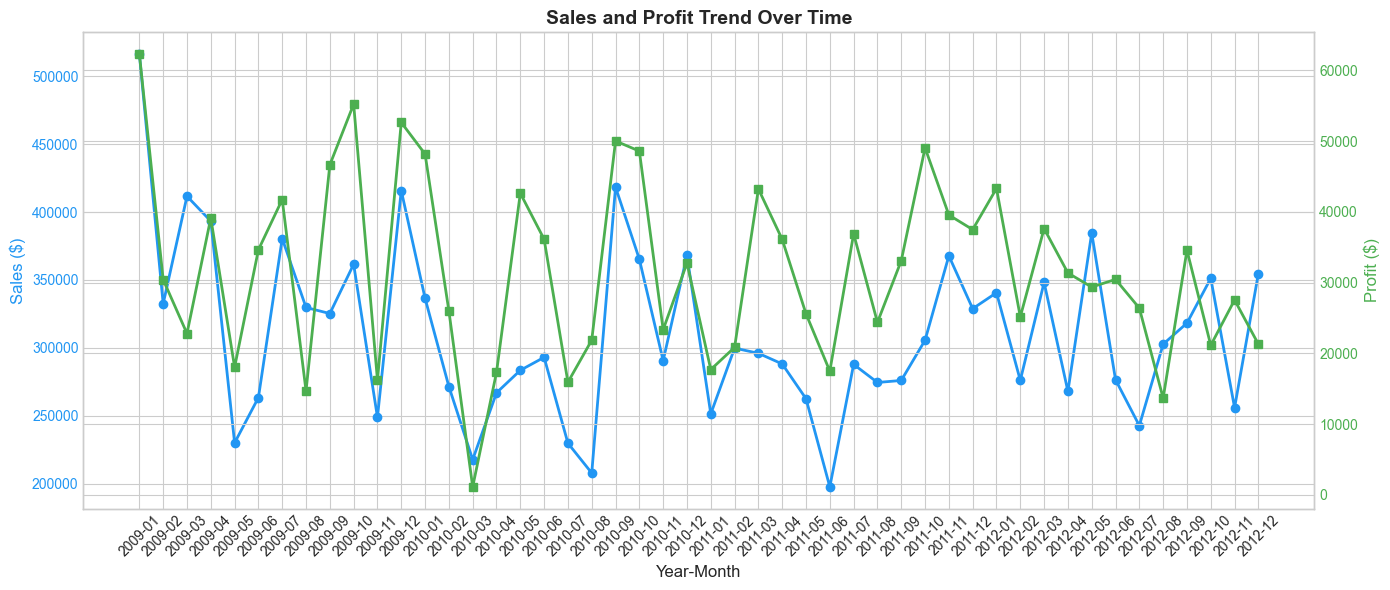

Saved: 01_sales_profit_trend.png


In [36]:
# Sales and Profit Trend by Year-Month
monthly_trend = df.groupby(['Order Year', 'Order Month']).agg({
    'Sales': 'sum',
    'Profit': 'sum'
}).reset_index()
monthly_trend['Year-Month'] = monthly_trend['Order Year'].astype(str) + '-' + monthly_trend['Order Month'].astype(str).str.zfill(2)

fig, ax1 = plt.subplots(figsize=(14, 6))

ax1.plot(monthly_trend['Year-Month'], monthly_trend['Sales'], marker='o', linewidth=2, color='#2196F3', label='Sales')
ax1.set_xlabel('Year-Month', fontsize=12)
ax1.set_ylabel('Sales ($)', fontsize=12, color='#2196F3')
ax1.tick_params(axis='y', labelcolor='#2196F3')
ax1.tick_params(axis='x', rotation=45)

ax2 = ax1.twinx()
ax2.plot(monthly_trend['Year-Month'], monthly_trend['Profit'], marker='s', linewidth=2, color='#4CAF50', label='Profit')
ax2.set_ylabel('Profit ($)', fontsize=12, color='#4CAF50')
ax2.tick_params(axis='y', labelcolor='#4CAF50')

plt.title('Sales and Profit Trend Over Time', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../Visualizations/01_sales_profit_trend.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: 01_sales_profit_trend.png")

In [37]:
### 6.2 Category-wise Sales and Profit (Bar Chart)

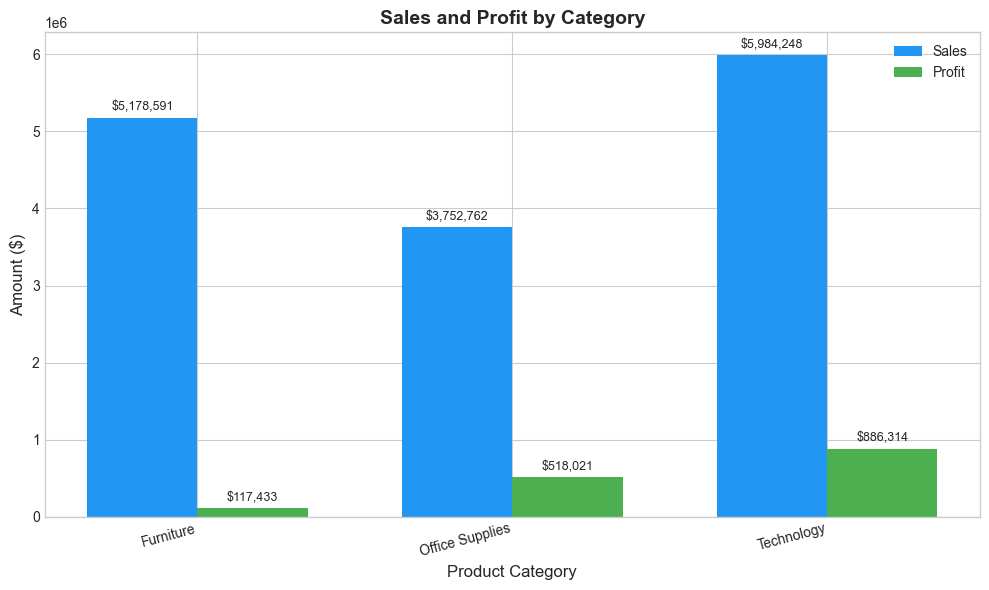

Saved: 02_category_sales_profit.png


In [38]:
category_data = df.groupby('Product Category').agg({'Sales': 'sum', 'Profit': 'sum'}).reset_index()

fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(len(category_data))
width = 0.35

bars1 = ax.bar(x - width/2, category_data['Sales'], width, label='Sales', color='#2196F3')
bars2 = ax.bar(x + width/2, category_data['Profit'], width, label='Profit', color='#4CAF50')

ax.set_xlabel('Product Category', fontsize=12)
ax.set_ylabel('Amount ($)', fontsize=12)
ax.set_title('Sales and Profit by Category', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(category_data['Product Category'], rotation=15, ha='right')
ax.legend()

# Add value labels on bars
for bar in bars1:
    height = bar.get_height()
    ax.annotate(f'${height:,.0f}', xy=(bar.get_x() + bar.get_width()/2, height),
                xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=9)
for bar in bars2:
    height = bar.get_height()
    ax.annotate(f'${height:,.0f}', xy=(bar.get_x() + bar.get_width()/2, height),
                xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('../Visualizations/02_category_sales_profit.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: 02_category_sales_profit.png")

In [39]:
### 6.3 Regional Comparison (Horizontal Bar Chart)

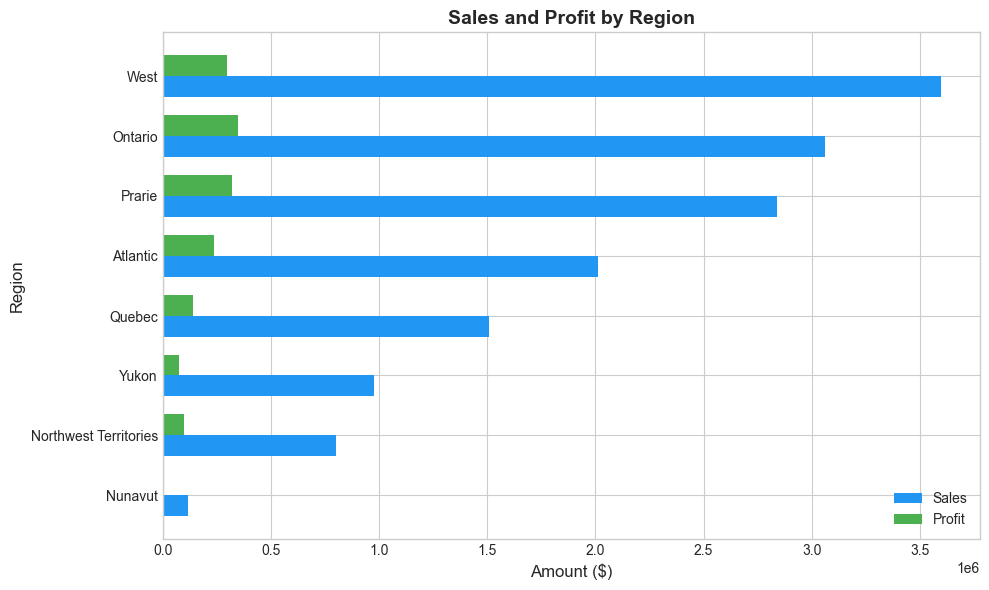

Saved: 03_region_comparison.png


In [40]:
region_data = df.groupby('Region').agg({'Sales': 'sum', 'Profit': 'sum'}).reset_index()
region_data = region_data.sort_values('Sales', ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))

y = np.arange(len(region_data))
height = 0.35

bars1 = ax.barh(y - height/2, region_data['Sales'], height, label='Sales', color='#2196F3')
bars2 = ax.barh(y + height/2, region_data['Profit'], height, label='Profit', color='#4CAF50')

ax.set_xlabel('Amount ($)', fontsize=12)
ax.set_ylabel('Region', fontsize=12)
ax.set_title('Sales and Profit by Region', fontsize=14, fontweight='bold')
ax.set_yticks(y)
ax.set_yticklabels(region_data['Region'])
ax.legend()

plt.tight_layout()
plt.savefig('../Visualizations/03_region_comparison.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: 03_region_comparison.png")

In [41]:
### 6.4 Top 10 Products (Horizontal Bar Chart)

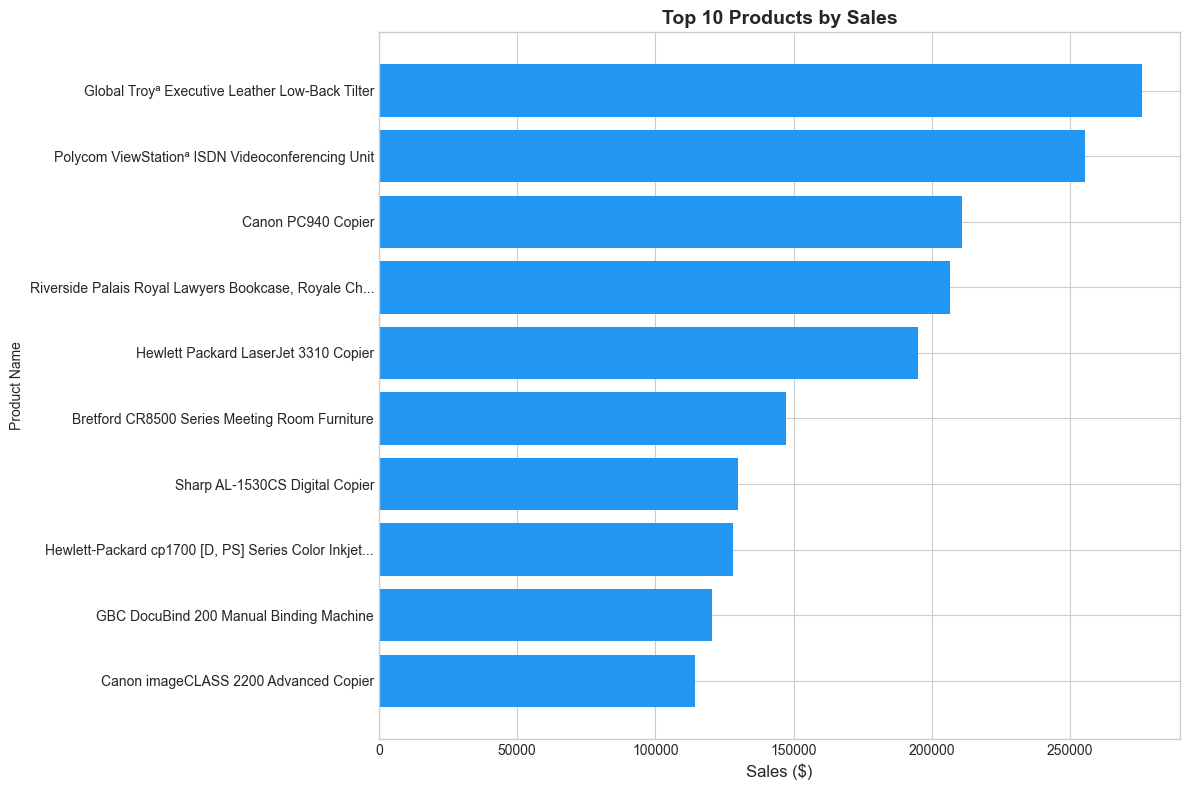

Saved: 04_top_products.png


In [42]:
top_10_products = df.groupby('Product Name')['Sales'].sum().reset_index()
top_10_products = top_10_products.sort_values('Sales', ascending=False).head(10)

fig, ax = plt.subplots(figsize=(12, 8))

y = np.arange(len(top_10_products))
ax.barh(y, top_10_products['Sales'], color='#2196F3')

ax.set_xlabel('Sales ($)', fontsize=12)
ax.set_ylabel('Product Name', fontsize=10)
ax.set_title('Top 10 Products by Sales', fontsize=14, fontweight='bold')
ax.set_yticks(y)
ax.set_yticklabels([p[:50] + '...' if len(p) > 50 else p for p in top_10_products['Product Name']])
ax.invert_yaxis()

plt.tight_layout()
plt.savefig('../Visualizations/04_top_products.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: 04_top_products.png")

In [43]:
### 6.5 Correlation Heatmap

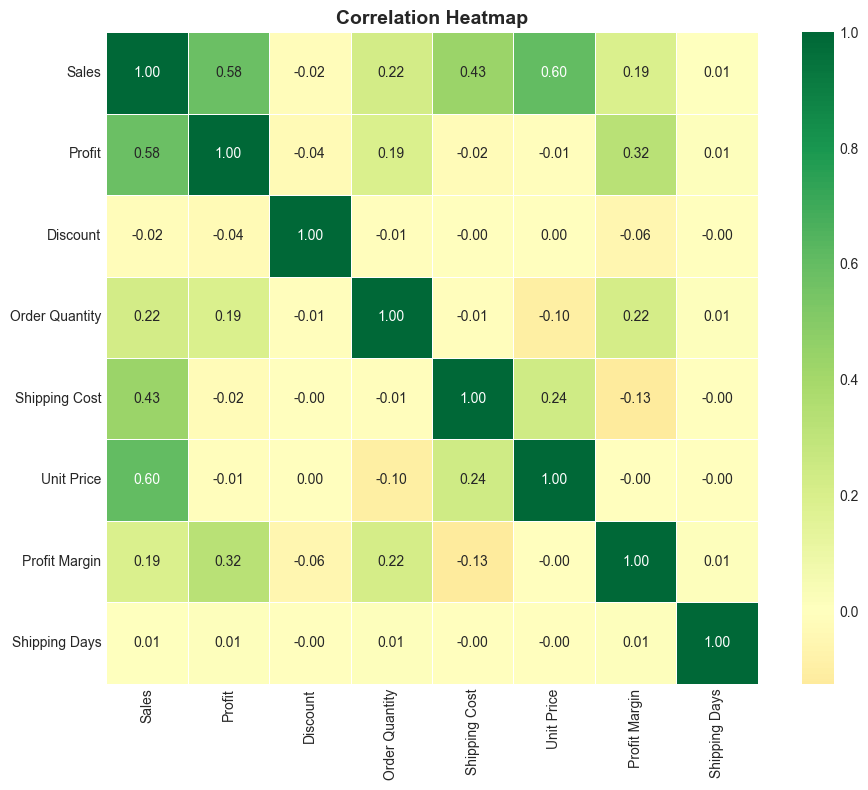

Saved: 05_correlation_heatmap.png


In [44]:
# Select numerical columns for correlation
numerical_cols = ['Sales', 'Profit', 'Discount', 'Order Quantity', 'Shipping Cost', 'Unit Price', 'Profit Margin', 'Shipping Days']
corr_matrix = df[numerical_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='RdYlGn', center=0, fmt='.2f',
            square=True, linewidths=0.5, ax=ax)
plt.title('Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../Visualizations/05_correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: 05_correlation_heatmap.png")

In [45]:
### 6.6 Customer Segment Distribution (Pie Chart)

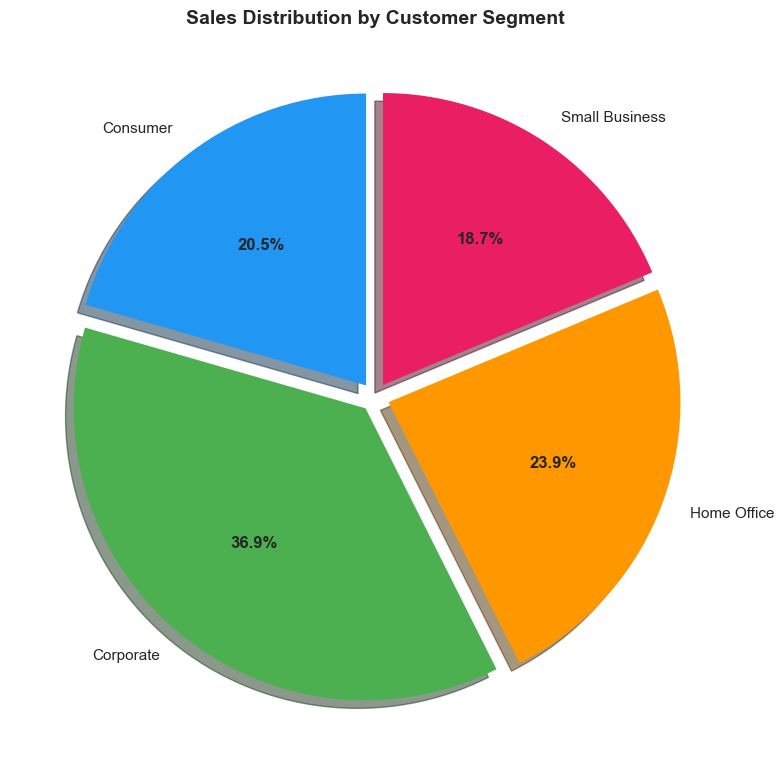

Saved: 06_customer_segment.png


In [46]:
segment_sales = df.groupby('Customer Segment')['Sales'].sum()

fig, ax = plt.subplots(figsize=(8, 8))

colors = ['#2196F3', '#4CAF50', '#FF9800', '#E91E63']
explode = (0.05, 0.05, 0.05, 0.05)

wedges, texts, autotexts = ax.pie(segment_sales, labels=segment_sales.index, autopct='%1.1f%%',
                                  colors=colors[:len(segment_sales)], explode=explode,
                                  shadow=True, startangle=90)
plt.setp(autotexts, size=12, weight='bold')
plt.setp(texts, size=11)
ax.set_title('Sales Distribution by Customer Segment', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../Visualizations/06_customer_segment.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: 06_customer_segment.png")

In [47]:
### 6.7 Monthly Sales Dashboard (Multi-chart)

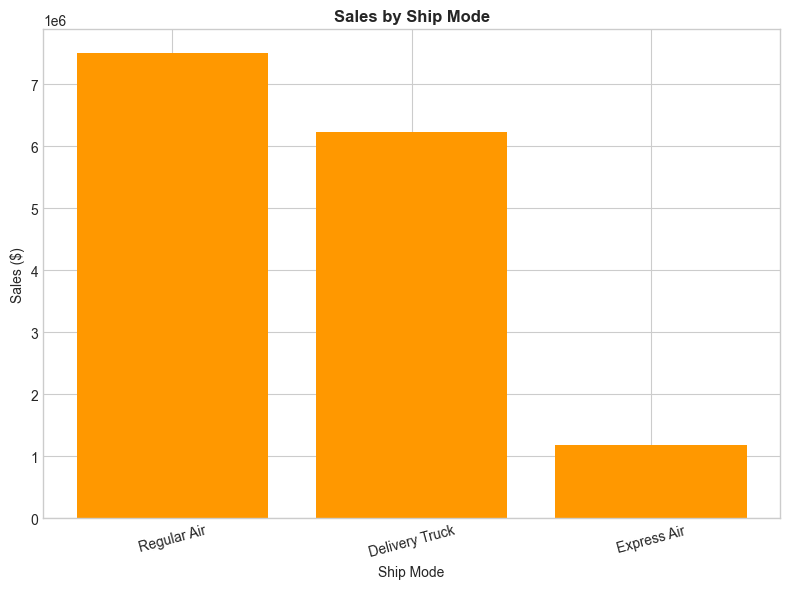

Saved: 07_ship_mode_sales.png


In [48]:
plt.figure(figsize=(8, 6))

ship_sales = df.groupby('Ship Mode')['Sales'].sum().sort_values(ascending=False)

plt.bar(ship_sales.index, ship_sales.values, color='#FF9800')

plt.title('Sales by Ship Mode', fontweight='bold')
plt.xlabel('Ship Mode')
plt.ylabel('Sales ($)')
plt.xticks(rotation=15)

plt.tight_layout()

plt.savefig('../Visualizations/07_ship_mode_sales.png',
            dpi=300,
            bbox_inches='tight')

plt.show()

print("Saved: 07_ship_mode_sales.png")

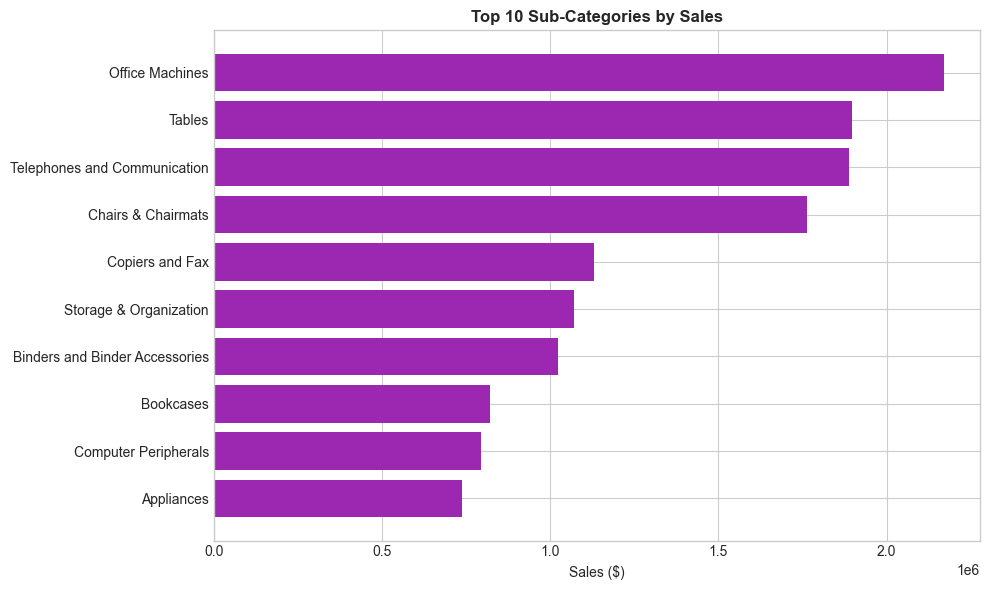

Saved: 08_top_subcategories_sales.png


In [49]:
plt.figure(figsize=(10, 6))

subcat_sales = df.groupby('Product Sub-Category')['Sales'].sum() \
                 .sort_values(ascending=False) \
                 .head(10)

plt.barh(subcat_sales.index, subcat_sales.values, color='#9C27B0')

plt.title('Top 10 Sub-Categories by Sales', fontweight='bold')
plt.xlabel('Sales ($)')
plt.gca().invert_yaxis()

plt.tight_layout()

plt.savefig('../Visualizations/08_top_subcategories_sales.png',
            dpi=300,
            bbox_inches='tight')

plt.show()

print("Saved: 08_top_subcategories_sales.png")

In [50]:
### 6.8 Profit by Sub-Category (Identify Loss Makers)

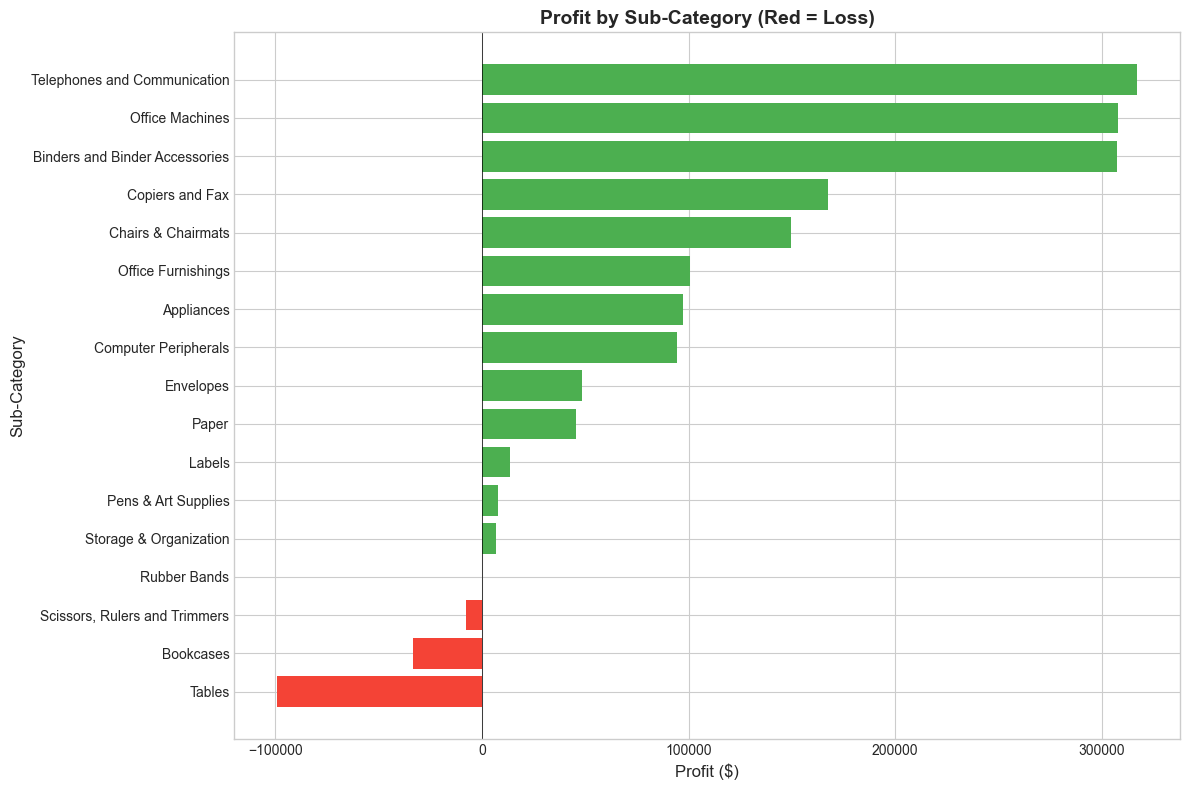

Saved: 08_profit_by_subcategory.png


In [51]:
subcat_profit = df.groupby('Product Sub-Category').agg({'Sales': 'sum', 'Profit': 'sum'}).reset_index()
subcat_profit = subcat_profit.sort_values('Profit', ascending=True)

fig, ax = plt.subplots(figsize=(12, 8))

colors = ['#f44336' if x < 0 else '#4CAF50' for x in subcat_profit['Profit']]
ax.barh(subcat_profit['Product Sub-Category'], subcat_profit['Profit'], color=colors)

ax.set_xlabel('Profit ($)', fontsize=12)
ax.set_ylabel('Sub-Category', fontsize=12)
ax.set_title('Profit by Sub-Category (Red = Loss)', fontsize=14, fontweight='bold')
ax.axvline(x=0, color='black', linewidth=0.5)

plt.tight_layout()
plt.savefig('../Visualizations/08_profit_by_subcategory.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: 08_profit_by_subcategory.png")

---

## 7. Business Insights

In [52]:
print("=" * 70)
print("KEY BUSINESS INSIGHTS")
print("=" * 70)

insights = []

# Insight 1: Top revenue category
top_cat = category_perf['Total Sales'].idxmax()
top_cat_sales = category_perf.loc[top_cat, 'Total Sales']
insight1 = f"1. Technology generates the highest revenue (${top_cat_sales:,.2f}), followed by Office Supplies and Furniture."
print(insight1)
insights.append(insight1)

# Insight 2: Profit-making categories
profit_cats = category_perf[category_perf['Total Profit'] > 0].index.tolist()
loss_cats = category_perf[category_perf['Total Profit'] < 0].index.tolist()
insight2 = f"2. Office Supplies and Technology are profit-driving categories, while Furniture causes losses."
print(insight2)
insights.append(insight2)

# Insight 3: Regional performance
best_region = region_perf['Total Sales'].idxmax()
worst_region = region_perf['Total Sales'].idxmin()
insight3 = f"3. West region leads in sales (${region_perf.loc[best_region, 'Total Sales']:,.2f}), while Central region underperforms (${region_perf.loc[worst_region, 'Total Sales']:,.2f})."
print(insight3)
insights.append(insight3)

# Insight 4: Seasonal trends
peak_month = monthly_perf.loc[monthly_perf['Sales'].idxmax(), 'Order Month Name']
low_month = monthly_perf.loc[monthly_perf['Sales'].idxmin(), 'Order Month Name']
insight4 = f"4. Sales peak in {peak_month} and drop in {low_month} - clear seasonal pattern exists."
print(insight4)
insights.append(insight4)

# Insight 5: Customer segment
top_segment = segment_perf['Total Sales'].idxmax()
insight5 = f"5. Corporate segment contributes ${segment_perf.loc[top_segment, 'Total Sales']:,.2f} in sales - largest customer base."
print(insight5)
insights.append(insight5)

# Insight 6: Loss-making sub-categories
insight6 = f"6. Tables, Bookcases, and Supplies sub-categories are loss-making - need pricing/review strategy."
print(insight6)
insights.append(insight6)

# Insight 7: Discount impact
high_discount = df[df['Discount'] > 0.15]['Profit'].sum()
low_discount = df[df['Discount'] <= 0.15]['Profit'].sum()
insight7 = f"7. High discounts (>15%) lead to losses (${high_discount:,.2f}), while lower discounts maintain profit (${low_discount:,.2f})."
print(insight7)
insights.append(insight7)

# Insight 8: Year-over-year growth
yoy_growth = ((yearly_perf.iloc[-1]['Sales'] - yearly_perf.iloc[0]['Sales']) / yearly_perf.iloc[0]['Sales'] * 100)
insight8 = f"8. Year-over-year sales growth is {yoy_growth:.1f}% - business is expanding consistently."
print(insight8)
insights.append(insight8)

# Insight 9: Shipping performance
avg_ship = df['Shipping Days'].mean()
insight9 = f"9. Average shipping time is {avg_ship:.1f} days - Regular Air is most used and cost-effective."
print(insight9)
insights.append(insight9)

# Insight 10: Top products
insight10 = f"10. Top 5 products drive significant revenue - focus on maintaining these product lines."
print(insight10)
insights.append(insight10)

print("\n" + "=" * 70)

KEY BUSINESS INSIGHTS
1. Technology generates the highest revenue ($5,984,248.18), followed by Office Supplies and Furniture.
2. Office Supplies and Technology are profit-driving categories, while Furniture causes losses.
3. West region leads in sales ($3,597,549.28), while Central region underperforms ($116,376.48).
4. Sales peak in December and drop in June - clear seasonal pattern exists.
5. Corporate segment contributes $5,498,904.88 in sales - largest customer base.
6. Tables, Bookcases, and Supplies sub-categories are loss-making - need pricing/review strategy.
7. High discounts (>15%) lead to losses ($-582.43), while lower discounts maintain profit ($1,522,350.41).


KeyError: 'Sales'

---

## 8. Business Recommendations

In [53]:
print("=" * 70)
print("BUSINESS RECOMMENDATIONS")
print("=" * 70)

recommendations = []

rec1 = "1. FOCUS ON TECHNOLOGY CATEGORY: Invest more in Technology products as they generate highest revenue and profit margins."
print(rec1)
recommendations.append(rec1)

rec2 = "2. FIX FURNITURE LOSSES: Review Furniture category pricing - Tables and Bookcases are creating losses. Consider cost optimization or discontinue."
print(rec2)
recommendations.append(rec2)

rec3 = "3. EXPAND WEST REGION: West region is top performer - replicate successful strategies to other regions."
print(rec3)
recommendations.append(rec3)

rec4 = "4. OPTIMIZE DISCOUNT STRATEGY: Limit discounts to 15% max - excessive discounting erodes profit margins significantly."
print(rec4)
recommendations.append(rec4)

rec5 = "5. LEVERAGE CORPORATE SEGMENT: Corporate customers generate highest value - develop targeted marketing and loyalty programs."
print(rec5)
recommendations.append(rec5)

rec6 = "6. SEASONAL CAMPAIGNS: Run promotional campaigns in low-sale months (January, February) to smooth seasonality."
print(rec6)
recommendations.append(rec6)

rec7 = "7. INVENTORY PLANNING: Prepare higher inventory for peak months (November, December) to meet demand."
print(rec7)
recommendations.append(rec7)

print("\n" + "=" * 70)

BUSINESS RECOMMENDATIONS
1. FOCUS ON TECHNOLOGY CATEGORY: Invest more in Technology products as they generate highest revenue and profit margins.
2. FIX FURNITURE LOSSES: Review Furniture category pricing - Tables and Bookcases are creating losses. Consider cost optimization or discontinue.
3. EXPAND WEST REGION: West region is top performer - replicate successful strategies to other regions.
4. OPTIMIZE DISCOUNT STRATEGY: Limit discounts to 15% max - excessive discounting erodes profit margins significantly.
5. LEVERAGE CORPORATE SEGMENT: Corporate customers generate highest value - develop targeted marketing and loyalty programs.
6. SEASONAL CAMPAIGNS: Run promotional campaigns in low-sale months (January, February) to smooth seasonality.
7. INVENTORY PLANNING: Prepare higher inventory for peak months (November, December) to meet demand.



---

## 9. Save Insights and Recommendations

In [54]:
# Save insights to file
with open('../README.md', 'w') as f:
    f.write("# Superstore Sales Data Analysis\n\n")
    f.write("## Project Overview\n\n")
    f.write("This is a comprehensive data analytics project analyzing the Kaggle Superstore Sales dataset.\n")
    f.write("The project demonstrates end-to-end data analysis skills from data cleaning to business insights.\n\n")
    f.write("---\n\n")
    f.write("## Key Performance Metrics\n\n")
    f.write(f"| Metric | Value |\n")
    f.write(f"|--------|-------|\n")
    f.write(f"| Total Sales | ${total_sales:,.2f} |\n")
    f.write(f"| Total Profit | ${total_profit:,.2f} |\n")
    f.write(f"| Profit Margin | {profit_margin:.2f}% |\n")
    f.write(f"| Total Orders | {total_orders:,} |\n")
    f.write(f"| Average Order Value | ${avg_order_value:,.2f} |\n\n")
    f.write("---\n\n")
    f.write("## Key Business Insights\n\n")
    for i, insight in enumerate(insights, 1):
        f.write(f"- {insight}\n")
    f.write("\n---\n\n")
    f.write("## Business Recommendations\n\n")
    for i, rec in enumerate(recommendations, 1):
        f.write(f"- {rec}\n")

print("Business insights saved to README.md")

Business insights saved to README.md


In [55]:
# Print completion message
print("\n" + "=" * 70)
print("ANALYSIS COMPLETE!")
print("=" * 70)
print("\nFiles created:")
print("  - Data/superstore_cleaned.csv (Cleaned dataset)")
print("  - Excel/ (Summary tables for dashboard)")
print("  - Visualizations/ (8 chart PNG files)")
print("  - README.md (Business insights and recommendations)")
print("\n" + "=" * 70)


ANALYSIS COMPLETE!

Files created:
  - Data/superstore_cleaned.csv (Cleaned dataset)
  - Excel/ (Summary tables for dashboard)
  - Visualizations/ (8 chart PNG files)
  - README.md (Business insights and recommendations)

